# 05 Exploratory Baseline ML ของ LABAI

notebook นี้เป็นการทดลอง model ระดับจังหวัดจากไฟล์ cleaned demand/supply จำนวน 77 แถว
clustering เป็น model หลัก ส่วน classification เป็น derived educational label และไม่มี regression ในรอบนี้

## Import libraries

cell นี้ import เฉพาะ library สำหรับการเตรียมข้อมูล, baseline ML, กราฟ และ HTML report

In [1]:
from pathlib import Path
from html import escape
import os
import tempfile

## ค้นหา root ของโครงการ

รองรับการเปิด notebook จาก `notebooks/` หรือจาก root ของโครงการ โดยตรวจหา `data/raw/` ที่มีอยู่จริง

In [2]:
def find_project_root():
    current_path = Path.cwd().resolve()
    candidate_paths = [current_path]
    candidate_paths.extend(current_path.parents)

    for candidate_path in candidate_paths:
        if (candidate_path / "data" / "raw").exists():
            return candidate_path

    raise FileNotFoundError("ไม่พบ root ของโครงการที่มี data/raw")


PROJECT_ROOT = find_project_root()

## ตั้งค่า runtime สำหรับกราฟ

กำหนด cache ชั่วคราวนอกโครงการและ backend แบบ non-interactive ก่อน import Matplotlib เพื่อไม่สร้างไฟล์ cache ใน public package

In [3]:
MPL_CONFIG_DIR = Path(tempfile.gettempdir()) / "dga306_matplotlib_cache"
MPL_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CONFIG_DIR))
os.environ.setdefault("MPLBACKEND", "Agg")

'module://matplotlib_inline.backend_inline'

## นำเข้าไลบรารีสำหรับข้อมูล, model และกราฟ

import library หลังตั้งค่า runtime เพื่อให้กราฟภาษาไทยและการสร้าง figure ทำงานใน environment headless

In [4]:
import matplotlib as mpl
mpl.use("Agg")
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display as display_image
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def display_figure(figure):
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=200, bbox_inches="tight")
    display_image(Image(data=buffer.getvalue()))
    buffer.close()
    plt.close(figure)

## ตั้งค่า font ภาษาไทย

ใช้ Sarabun ที่มีอยู่ในโครงการสำหรับกราฟภาษาไทย หากไม่พบไฟล์จะใช้ font มาตรฐานของระบบ และข้อความไทยอาจแสดงไม่สมบูรณ์

In [5]:
font_path = PROJECT_ROOT / "Sarabun-Regular.ttf"

if font_path.exists():
    mpl.font_manager.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = "Sarabun"
else:
    plt.rcParams["font.family"] = "sans-serif"

plt.rcParams["axes.unicode_minus"] = False

## Define paths

cell นี้กำหนด input จาก cleaned outputs และ output สำหรับกราฟกับ HTML report ของ Phase 4

In [6]:
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
HTML_REPORT_DIR = PROJECT_ROOT / "reports" / "html"

HTML_REPORT_DIR.mkdir(parents=True, exist_ok=True)

DEMAND_SUPPLY_FILE = PROCESSED_DATA_DIR / "labai_demand_supply_cleaned.csv"
LANDOWNERS_FILE = PROCESSED_DATA_DIR / "labai_landowners_cleaned.csv"
HTML_REPORT_FILE = HTML_REPORT_DIR / "ml_baseline_report.html"

## Load demand/supply data

ไฟล์นี้เป็น input หลักของ model ทุกตัวใน notebook และไม่มีการใช้ field การจับคู่เป็น target

In [7]:
demand_supply_df = pd.read_csv(DEMAND_SUPPLY_FILE, encoding="utf-8-sig")
demand_supply_df.head()

,PROVINCE_NAME,countw,count_want_land,area_rai_want_land,area_nga_want_land,area_wa_want_land,countowner,count_owner_land,area_rai_owner,area_nga_owner,...,province_name,area_rai_want_land_numeric,area_rai_want_land_has_placeholder,area_nga_want_land_numeric,area_nga_want_land_has_placeholder,area_rai_owner_numeric,area_rai_owner_has_placeholder,area_nga_owner_numeric,area_nga_owner_has_placeholder,count_gap_want_minus_owner
0,กรุงเทพมหานคร,164,39,0,2,53.0,36,1,0,2,...,กรุงเทพมหานคร,0,False,2,False,0,False,2,False,38
1,สมุทรปราการ,29,22,0,0,0.0,6,0,0,0,...,สมุทรปราการ,0,False,0,False,0,False,0,False,22
2,นนทบุรี,35,30,0,0,0.0,6,0,0,0,...,นนทบุรี,0,False,0,False,0,False,0,False,30
3,ปทุมธานี,44,72,1,0,0.0,2,1,1,0,...,ปทุมธานี,1,False,0,False,1,False,0,False,71
4,พระนครศรีอยุธยา,15,19,0,0,0.0,3,0,0,0,...,พระนครศรีอยุธยา,0,False,0,False,0,False,0,False,19


## Load landowners data

ไฟล์นี้โหลดเพื่อตรวจขอบเขตแหล่งข้อมูล แต่ไม่ใช้เป็น feature เพิ่ม เพราะมี column ซ้ำเชิงความหมายกับ demand/supply ที่ต้องยืนยัน metadata เพิ่มเติม

In [8]:
landowners_df = pd.read_csv(LANDOWNERS_FILE, encoding="utf-8-sig")
landowners_df.head()

,PROVINCE_NAME,countowner,count_owner_land,area_rai,area_nga,area_wa,province_name,area_rai_numeric,area_rai_has_placeholder,area_nga_numeric,area_nga_has_placeholder
0,กรุงเทพมหานคร,36,1,0,2,53.0,กรุงเทพมหานคร,0,False,2,False
1,สมุทรปราการ,6,0,0,0,0.0,สมุทรปราการ,0,False,0,False
2,นนทบุรี,6,0,0,0,0.0,นนทบุรี,0,False,0,False
3,ปทุมธานี,2,1,1,0,0.0,ปทุมธานี,1,False,0,False
4,พระนครศรีอยุธยา,3,0,0,0,0.0,พระนครศรีอยุธยา,0,False,0,False


## Data source notes

ข้อมูลหลักมาจากชุดข้อมูลผู้ประสงค์และเจ้าของที่ดินที่ลงทะเบียนของโครงการตัวกลางที่ดิน
ผล model เป็น educational baseline สำหรับ 77 แถวที่ดาวน์โหลดเมื่อ 2026-07-10 เท่านั้น

In [9]:
source_notes_df = pd.DataFrame(
    [
        {
            "dataset": "demand_supply",
            "source_url": "https://data.go.th/dataset/65_dataset_11_03",
            "local_file": "data/processed/labai_demand_supply_cleaned.csv",
            "row_count": demand_supply_df.shape[0],
        },
        {
            "dataset": "landowners",
            "source_url": "https://data.go.th/dataset/65_dataset_11_01",
            "local_file": "data/processed/labai_landowners_cleaned.csv",
            "row_count": landowners_df.shape[0],
        },
    ]
)
source_notes_df

,dataset,source_url,local_file,row_count
0,demand_supply,https://data.go.th/dataset/65_dataset_11_03,data/processed/labai_demand_supply_cleaned.csv,77
1,landowners,https://data.go.th/dataset/65_dataset_11_01,data/processed/labai_landowners_cleaned.csv,77


## Schema review

ตารางนี้ยืนยัน column และ data type ที่พบจริงในไฟล์ demand/supply ก่อนสร้าง feature

In [10]:
schema_review_df = pd.DataFrame(
    {
        "column_name": demand_supply_df.columns.astype(str),
        "data_type": demand_supply_df.dtypes.astype(str).tolist(),
        "missing_count": demand_supply_df.isna().sum().tolist(),
    }
)
schema_review_df

,column_name,data_type,missing_count
0,PROVINCE_NAME,str,0
1,countw,int64,0
2,count_want_land,int64,0
3,area_rai_want_land,int64,0
4,area_nga_want_land,int64,0
5,area_wa_want_land,float64,0
6,countowner,int64,0
7,count_owner_land,int64,0
8,area_rai_owner,int64,0
9,area_nga_owner,int64,0


## กำหนด column ที่ใช้จริง

ใช้ column เชิงจำนวนและ area fields ที่ผ่าน cleaning แล้วเท่านั้น ไม่ใช้ชื่อจังหวัดเป็นตัวเลข และไม่ใช้ field การจับคู่

In [11]:
PROVINCE_COLUMN = "province_name"
DEMAND_COUNT_COLUMN = "count_want_land"
SUPPLY_COUNT_COLUMN = "count_owner_land"
GAP_COLUMN = "count_gap_want_minus_owner"

CLUSTER_FEATURE_COLUMNS = [
    "countw",
    DEMAND_COUNT_COLUMN,
    "countowner",
    SUPPLY_COUNT_COLUMN,
    "area_rai_want_land_numeric",
    "area_nga_want_land_numeric",
    "area_wa_want_land",
    "area_rai_owner_numeric",
    "area_nga_owner_numeric",
    "area_wa_owner",
]

CLASSIFICATION_FEATURE_COLUMNS = [
    "countw",
    "countowner",
    "area_rai_want_land_numeric",
    "area_nga_want_land_numeric",
    "area_wa_want_land",
    "area_rai_owner_numeric",
    "area_nga_owner_numeric",
    "area_wa_owner",
]

## สร้าง derived features แบบโปร่งใส

`count_gap_want_minus_owner` มีอยู่ใน cleaned output และมาจาก `count_want_land - count_owner_land`
cell นี้เพิ่ม ratio เฉพาะแถวที่ตัวหารมากกว่า 0 และเพิ่ม total activity สำหรับการอธิบาย profile เท่านั้น

In [12]:
modeling_df = demand_supply_df.copy()
valid_supply_mask = modeling_df[SUPPLY_COUNT_COLUMN] > 0
modeling_df["demand_supply_ratio_valid"] = np.nan
modeling_df.loc[valid_supply_mask, "demand_supply_ratio_valid"] = (
    modeling_df.loc[valid_supply_mask, DEMAND_COUNT_COLUMN]
    / modeling_df.loc[valid_supply_mask, SUPPLY_COUNT_COLUMN]
)
modeling_df["total_activity_count"] = (
    modeling_df[DEMAND_COUNT_COLUMN] + modeling_df[SUPPLY_COUNT_COLUMN]
)

## อธิบาย derived features

ratio ไม่ใช้เป็น feature ของ clustering เพราะมีแถวที่ตัวหารเป็นศูนย์และไวต่อค่าที่สูงมาก
total activity เป็นผลรวมเพื่อใช้สรุป profile ไม่ใช่ feature เพิ่มของ clustering เพราะมีส่วนประกอบซ้ำกับ count fields

In [13]:
derived_feature_definitions_df = pd.DataFrame(
    [
        {
            "feature": GAP_COLUMN,
            "definition": "count_want_land - count_owner_land จาก cleaned output",
            "use": "ใช้สรุปและสร้าง derived label เท่านั้น",
        },
        {
            "feature": "demand_supply_ratio_valid",
            "definition": "count_want_land / count_owner_land เฉพาะแถวที่ count_owner_land มากกว่า 0",
            "use": "ใช้ตรวจข้อมูล ไม่ใช้เป็น clustering feature",
        },
        {
            "feature": "total_activity_count",
            "definition": "count_want_land + count_owner_land",
            "use": "ใช้ตีความ cluster profile ไม่ใช้เป็น clustering feature",
        },
    ]
)
derived_feature_definitions_df

,feature,definition,use
0,count_gap_want_minus_owner,count_want_land - count_owner_land จาก cleaned...,ใช้สรุปและสร้าง derived label เท่านั้น
1,demand_supply_ratio_valid,count_want_land / count_owner_land เฉพาะแถวที่...,ใช้ตรวจข้อมูล ไม่ใช้เป็น clustering feature
2,total_activity_count,count_want_land + count_owner_land,ใช้ตีความ cluster profile ไม่ใช้เป็น clusterin...


## ตรวจ outlier ด้วย IQR

การตรวจนี้นับค่าที่อยู่นอกช่วง IQR เพื่อบันทึกความเสี่ยงของ KMeans ซึ่งไวต่อ outlier
ไม่ลบหรือแก้ค่า outlier ใน notebook นี้

In [14]:
def count_iqr_outliers(series):
    first_quartile = series.quantile(0.25)
    third_quartile = series.quantile(0.75)
    interquartile_range = third_quartile - first_quartile
    lower_bound = first_quartile - 1.5 * interquartile_range
    upper_bound = third_quartile + 1.5 * interquartile_range
    return int(((series < lower_bound) | (series > upper_bound)).sum())

## สรุปจำนวน outlier ของ clustering features

ผลลัพธ์ช่วยอธิบายข้อจำกัดของ baseline ไม่ได้ใช้ตัดข้อมูลออก

In [15]:
outlier_records = []

for feature_name in CLUSTER_FEATURE_COLUMNS:
    outlier_records.append(
        {
            "feature": feature_name,
            "iqr_outlier_count": count_iqr_outliers(modeling_df[feature_name]),
        }
    )

outlier_summary_df = pd.DataFrame(outlier_records)
outlier_summary_df

,feature,iqr_outlier_count
0,countw,11
1,count_want_land,7
2,countowner,5
3,count_owner_land,9
4,area_rai_want_land_numeric,15
5,area_nga_want_land_numeric,15
6,area_wa_want_land,19
7,area_rai_owner_numeric,15
8,area_nga_owner_numeric,15
9,area_wa_owner,19


## Prepare modeling dataset for clustering

ใช้ numeric features ที่ไม่มี missing value แล้วทำ standardization เพื่อไม่ให้หน่วยและขนาดของ column เดียวครอบงำระยะห่าง

In [16]:
clustering_feature_df = modeling_df[CLUSTER_FEATURE_COLUMNS].copy()
clustering_scaler = StandardScaler()
clustering_feature_array = clustering_scaler.fit_transform(clustering_feature_df)

## Evaluate KMeans ด้วยหลายค่า k

ทดสอบ k จำนวนเล็กน้อยและใช้ silhouette score เปรียบเทียบความแยกของกลุ่ม
score เป็นแนวทางเลือก k ไม่ใช่หลักฐานว่ากลุ่มมีความหมายเชิงนโยบาย

In [17]:
candidate_cluster_counts = [2, 3, 4, 5]
silhouette_records = []

for cluster_count in candidate_cluster_counts:
    candidate_model = KMeans(n_clusters=cluster_count, random_state=42, n_init=20)
    candidate_labels = candidate_model.fit_predict(clustering_feature_array)
    silhouette_records.append(
        {
            "k": cluster_count,
            "silhouette_score": silhouette_score(clustering_feature_array, candidate_labels),
        }
    )

silhouette_scores_df = pd.DataFrame(silhouette_records)
silhouette_scores_df

C:\Users\User\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\User\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,silhouette_score
0,2,0.668124
1,3,0.675088
2,4,0.676858
3,5,0.677605


## เลือก k สำหรับ clustering baseline

เลือก k=3 เพราะคะแนนใกล้กับค่าที่สูงกว่าและให้จำนวนกลุ่มที่อธิบายได้ง่ายกว่าในการสาธิต
การเลือกนี้ไม่ได้อ้างว่า 3 เป็นจำนวนกลุ่มจริงของจังหวัดทั้งหมด

In [18]:
SELECTED_CLUSTER_COUNT = 3

## Train KMeans baseline

model นี้จัดกลุ่มจังหวัดจาก count และ area fields ที่ระบุไว้ โดยใช้ random state คงที่เพื่อให้ทำซ้ำได้

In [19]:
kmeans_model = KMeans(
    n_clusters=SELECTED_CLUSTER_COUNT,
    random_state=42,
    n_init=20,
)
modeling_df["cluster_id"] = kmeans_model.fit_predict(clustering_feature_array)

## สร้างแกน PCA สำหรับแสดงผล clustering

PCA ใช้ลดมิติของ clustering features เหลือ 2 แกนเพื่อสร้างกราฟ ไม่ได้ใช้แทน feature ทั้งหมดในการ train KMeans

In [20]:
pca_model = PCA(n_components=2, random_state=42)
pca_components = pca_model.fit_transform(clustering_feature_array)
modeling_df["pca_component_1"] = pca_components[:, 0]
modeling_df["pca_component_2"] = pca_components[:, 1]

## กราฟผล clustering

แหล่งข้อมูลคือ cleaned demand/supply ใช้ clustering features ที่ standardize แล้วและแสดงผ่าน PCA
กราฟตอบคำถามว่าจังหวัดที่มีรูปแบบ feature คล้ายกันอยู่ใกล้กันหรือไม่
ระยะห่างและสีเป็นผลของ baseline model ไม่ใช่การจัดอันดับศักยภาพหรือความเสี่ยงของจังหวัด

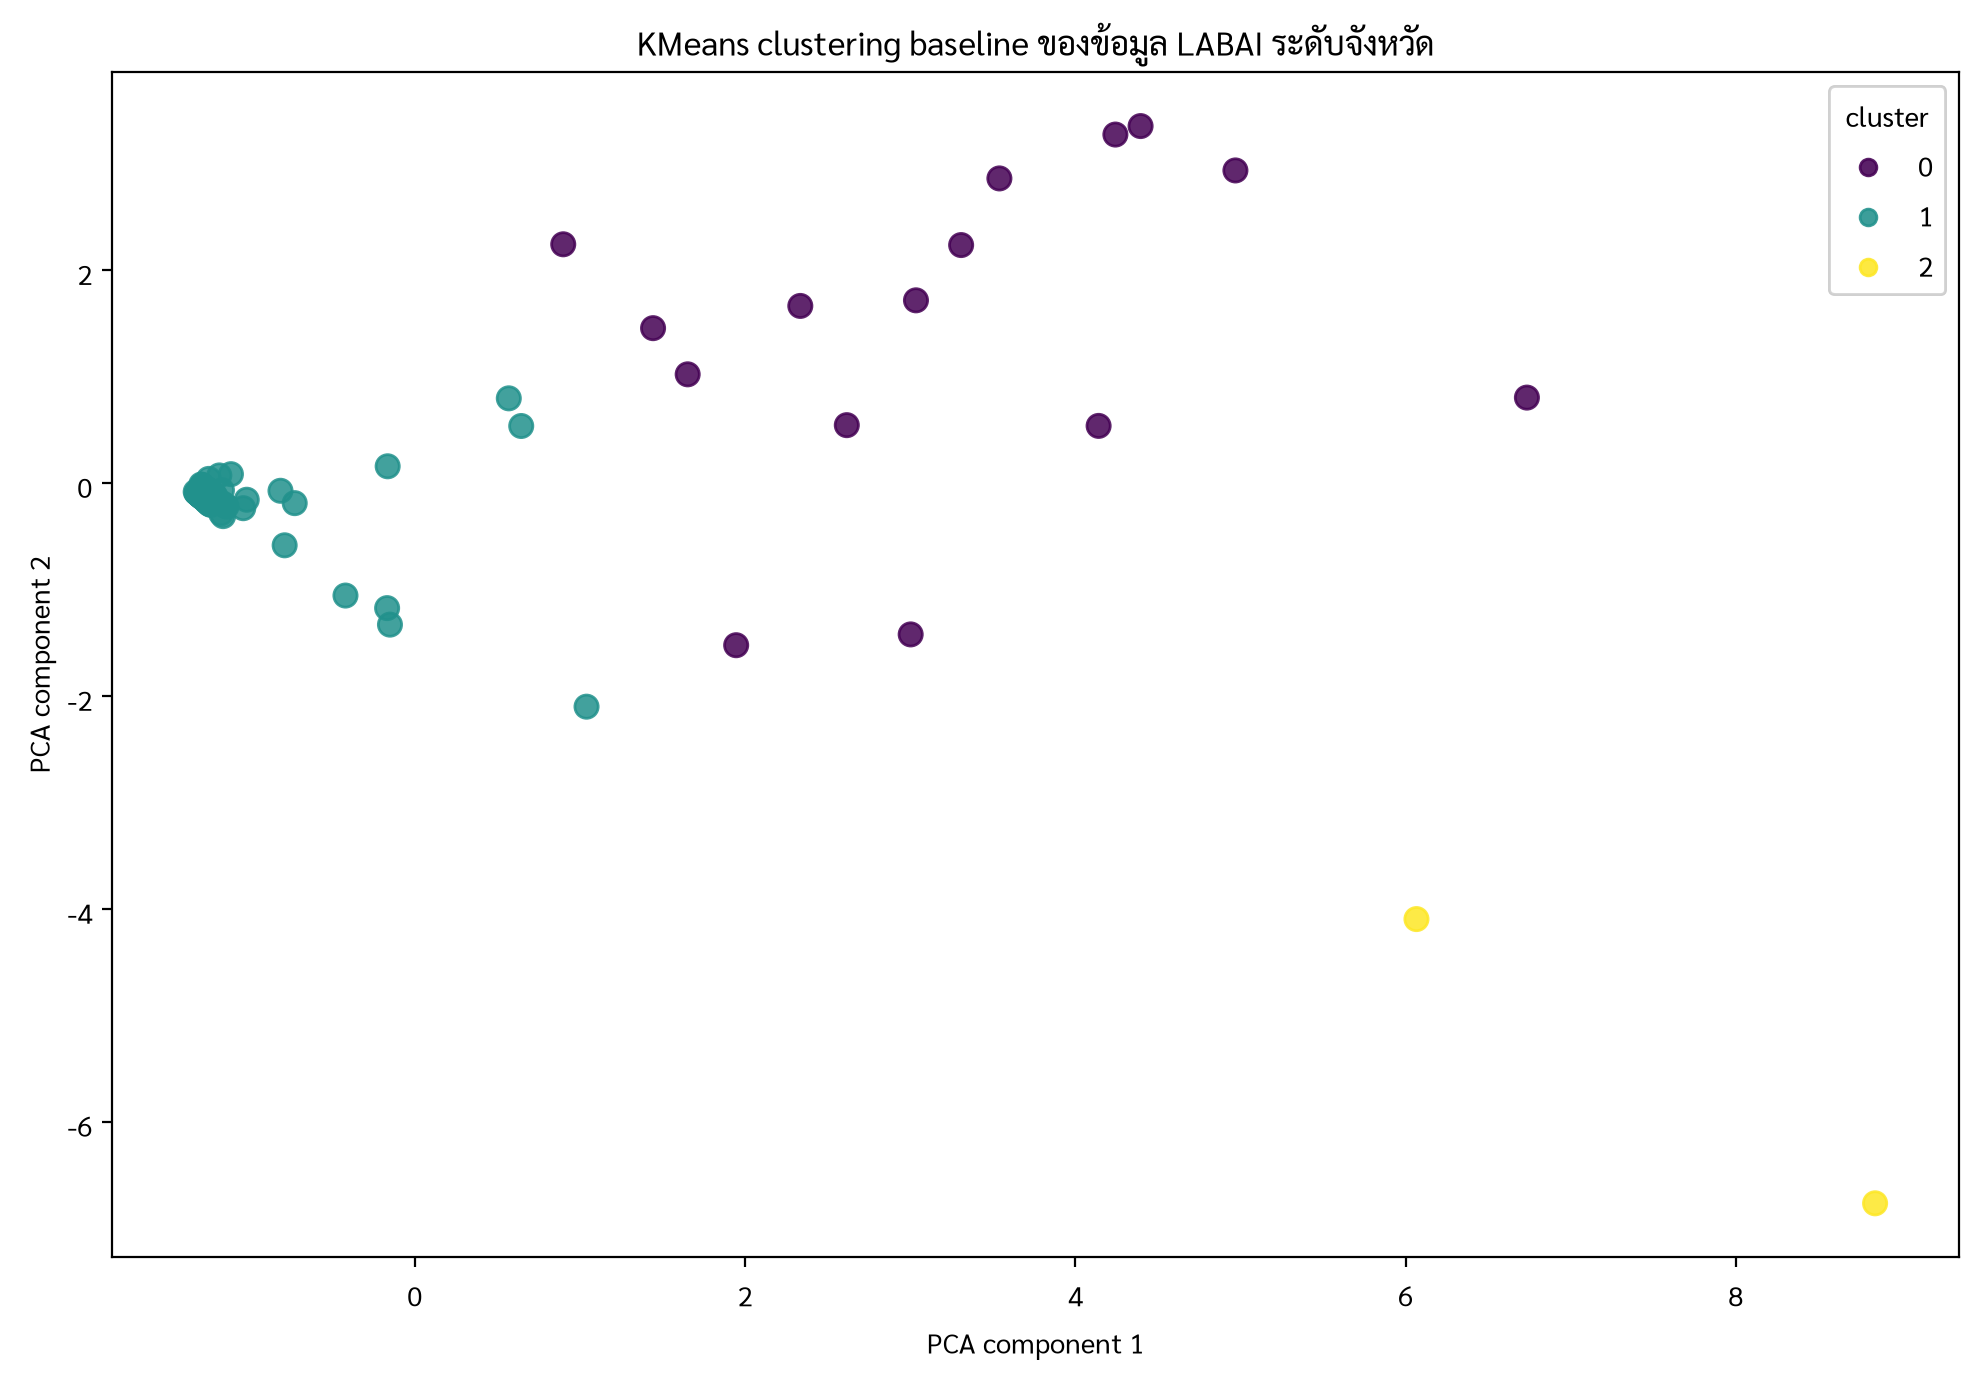

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    modeling_df["pca_component_1"],
    modeling_df["pca_component_2"],
    c=modeling_df["cluster_id"],
    cmap="viridis",
    s=70,
    alpha=0.85,
)
legend = ax.legend(*scatter.legend_elements(), title="cluster")
ax.add_artist(legend)
ax.set_title("KMeans clustering baseline ของข้อมูล LABAI ระดับจังหวัด")
ax.set_xlabel("PCA component 1")
ax.set_ylabel("PCA component 2")
fig.tight_layout()
display_figure(fig)

## สรุป cluster profile

ตารางนี้แสดงค่าเฉลี่ยและจำนวนจังหวัดต่อ cluster เพื่ออธิบายลักษณะของกลุ่มจาก column จริง
หมายเลข cluster เป็นรหัสจาก KMeans ไม่มีลำดับเชิงคุณภาพ

In [22]:
cluster_profile_columns = [
    "countw",
    DEMAND_COUNT_COLUMN,
    "countowner",
    SUPPLY_COUNT_COLUMN,
    GAP_COLUMN,
    "total_activity_count",
]
cluster_profiles_df = modeling_df.groupby("cluster_id")[cluster_profile_columns].mean().reset_index()
cluster_sizes_df = modeling_df.groupby("cluster_id").size().reset_index(name="province_count")
cluster_profiles_df = cluster_profiles_df.merge(cluster_sizes_df, on="cluster_id", how="left")
cluster_profiles_df

,cluster_id,countw,count_want_land,countowner,count_owner_land,count_gap_want_minus_owner,total_activity_count,province_count
0,0,26.133333,22.666667,5.266667,2.600000,20.066667,25.266667,15
1,1,7.300000,9.250000,0.916667,0.183333,9.066667,9.433333,60
2,2,233.000000,238.000000,0.000000,15.000000,223.000000,253.000000,2


## กราฟ cluster profile

กราฟ heatmap แสดงค่าเฉลี่ยของ profile columns หลัง standardization ระหว่าง cluster เพื่อให้เปรียบเทียบขนาดได้
ค่าบวกหรือลบในกราฟเป็นตำแหน่งสัมพัทธ์ต่อค่าเฉลี่ยระหว่าง cluster ไม่ใช่หน่วยข้อมูลต้นฉบับ

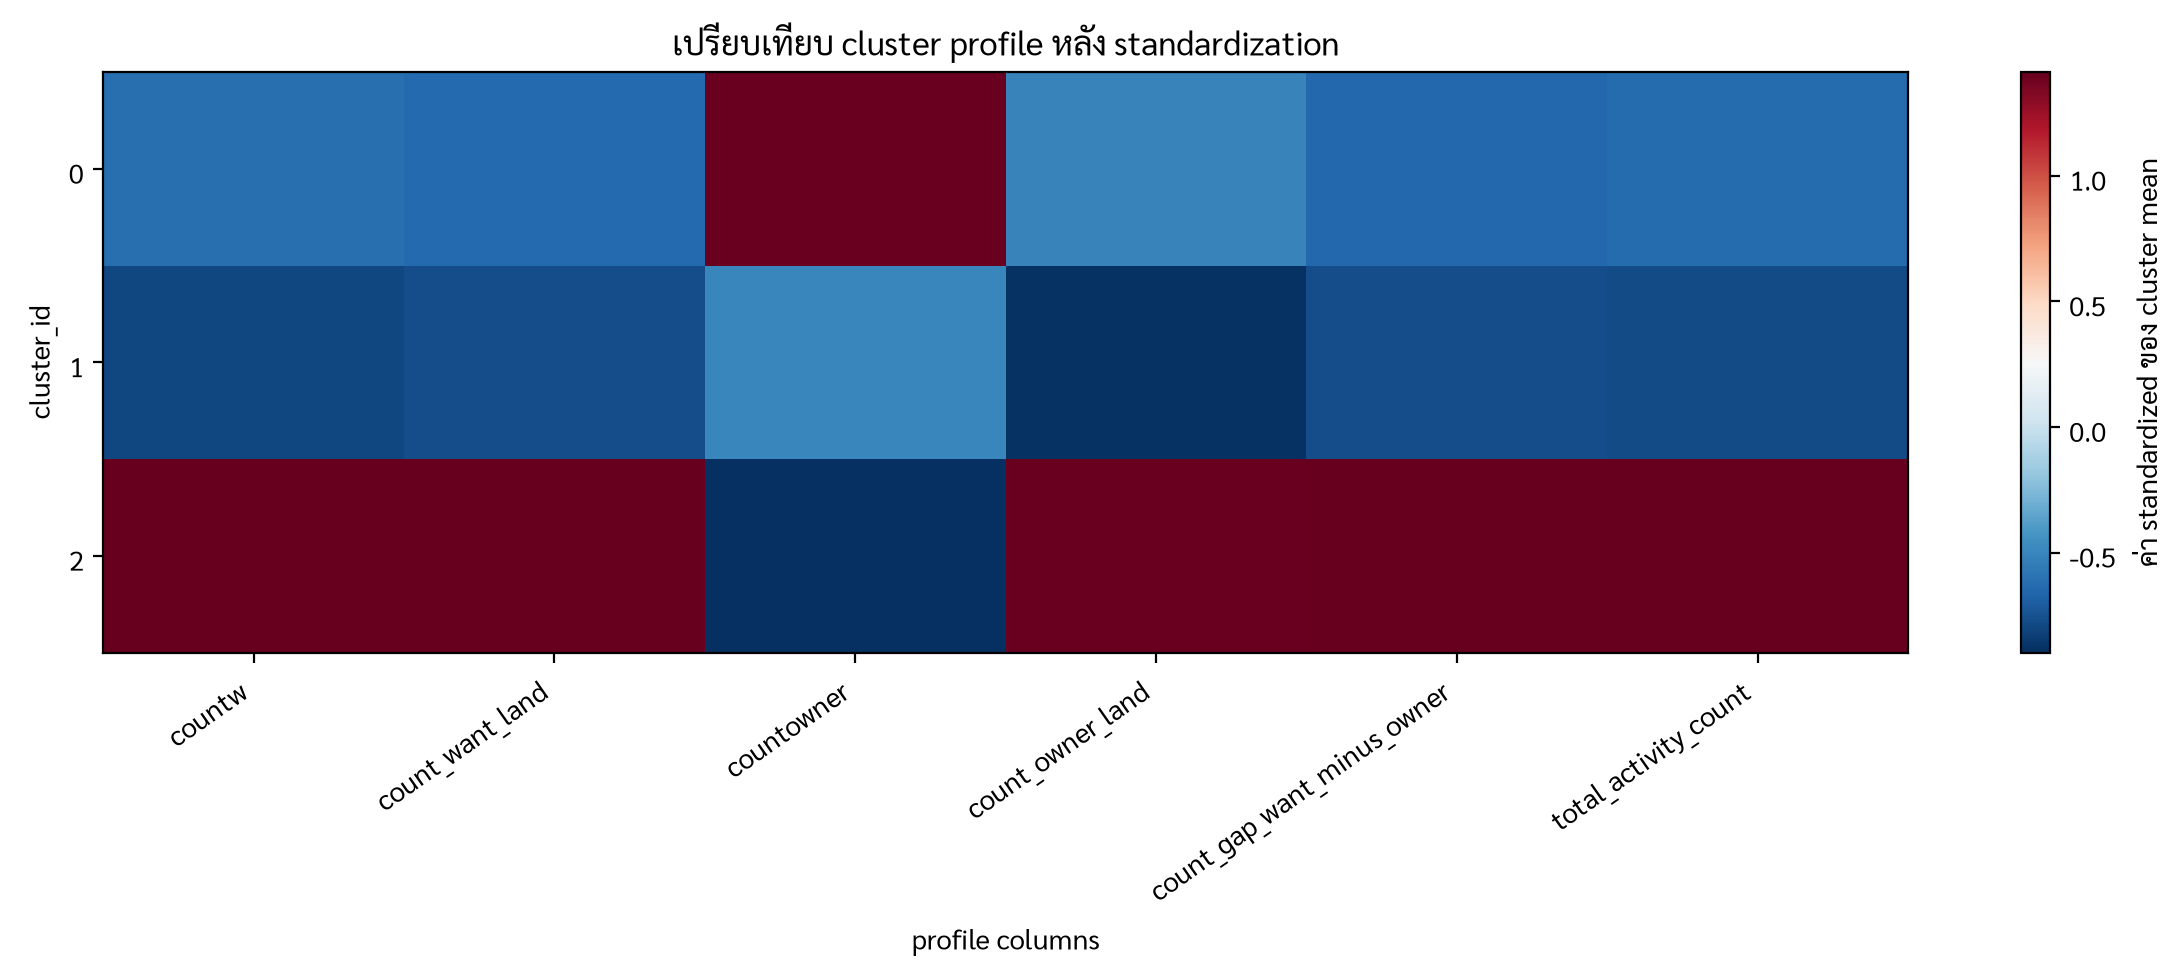

In [23]:
profile_value_columns = cluster_profile_columns
profile_scaler = StandardScaler()
standardized_profile_array = profile_scaler.fit_transform(
    cluster_profiles_df[profile_value_columns]
)

fig, ax = plt.subplots(figsize=(12, 5))
heatmap = ax.imshow(standardized_profile_array, cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(len(profile_value_columns)))
ax.set_xticklabels(profile_value_columns, rotation=35, ha="right")
ax.set_yticks(range(len(cluster_profiles_df)))
ax.set_yticklabels(cluster_profiles_df["cluster_id"].astype(str))
ax.set_xlabel("profile columns")
ax.set_ylabel("cluster_id")
ax.set_title("เปรียบเทียบ cluster profile หลัง standardization")
fig.colorbar(heatmap, ax=ax, label="ค่า standardized ของ cluster mean")
fig.tight_layout()
display_figure(fig)

## ตีความ cluster อย่างระมัดระวัง

ตารางนี้ใช้ค่าเฉลี่ยของ count fields และจำนวนจังหวัดเพื่อกำหนดประโยคอธิบายเชิงข้อมูล
ไม่ตั้งชื่อกลุ่มว่าเป็นความเสี่ยง, ศักยภาพ หรือผลการดำเนินงานของจังหวัด

In [24]:
cluster_interpretation_records = []

for profile_row in cluster_profiles_df.itertuples(index=False):
    cluster_interpretation_records.append(
        {
            "cluster_id": profile_row.cluster_id,
            "province_count": profile_row.province_count,
            "interpretation": (
                f"ค่าเฉลี่ย count_want_land {profile_row.count_want_land:.2f}, "
                f"count_owner_land {profile_row.count_owner_land:.2f}, "
                f"และ count_gap_want_minus_owner {profile_row.count_gap_want_minus_owner:.2f}"
            ),
        }
    )

cluster_interpretation_df = pd.DataFrame(cluster_interpretation_records)
cluster_interpretation_df

,cluster_id,province_count,interpretation
0,0,15,"ค่าเฉลี่ย count_want_land 22.67, count_owner_l..."
1,1,60,"ค่าเฉลี่ย count_want_land 9.25, count_owner_la..."
2,2,2,"ค่าเฉลี่ย count_want_land 238.00, count_owner_..."


## สร้าง derived label สำหรับ classification baseline

`high_gap` เป็น label เพื่อการศึกษา โดยกำหนดจาก quantile 75% ของ `count_gap_want_minus_owner`
label นี้ไม่ใช่สถานะทางการ และใช้เฉพาะเพื่อสาธิต workflow classification

In [25]:
high_gap_threshold = modeling_df[GAP_COLUMN].quantile(0.75)
modeling_df["high_gap"] = (modeling_df[GAP_COLUMN] >= high_gap_threshold).astype(int)

## ตรวจความสมดุลของ derived label

ตารางนี้แสดงจำนวนแถวของแต่ละ class ก่อนแบ่ง train-test split

In [26]:
class_balance_df = modeling_df["high_gap"].value_counts().sort_index().reset_index()
class_balance_df.columns = ["high_gap", "row_count"]
class_balance_df

,high_gap,row_count
0,0,56
1,1,21


## Prepare classification dataset

ไม่ใช้ `count_want_land`, `count_owner_land` หรือ `count_gap_want_minus_owner` เป็น feature เพราะมีส่วนในการนิยาม label
feature ที่เหลือยังต้องตีความอย่างระมัดระวัง เนื่องจาก metadata ของ count และ area fields มีข้อจำกัด

In [27]:
classification_feature_df = modeling_df[CLASSIFICATION_FEATURE_COLUMNS].copy()
classification_target_series = modeling_df["high_gap"].copy()
X_train, X_test, y_train, y_test = train_test_split(
    classification_feature_df,
    classification_target_series,
    test_size=0.25,
    random_state=42,
    stratify=classification_target_series,
)

## Train Logistic Regression baseline

ใช้ StandardScaler และ Logistic Regression แบบ class weight balanced เพื่อสาธิต baseline จาก derived label
model นี้ไม่ใช่ตัวทำนายสถานะทางการของจังหวัด

In [28]:
classification_model = Pipeline(
    [
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]
)
classification_model.fit(X_train, y_train)
classification_predictions = classification_model.predict(X_test)

## Evaluate classification baseline

ใช้ accuracy, precision, recall และ F1-score บน test set 20 แถว
metric มีความผันผวนสูงเพราะข้อมูลน้อยและ label ถูกสร้างขึ้นเพื่อการศึกษา

In [29]:
classification_metrics_df = pd.DataFrame(
    [
        {
            "accuracy": accuracy_score(y_test, classification_predictions),
            "precision": precision_score(y_test, classification_predictions, zero_division=0),
            "recall": recall_score(y_test, classification_predictions, zero_division=0),
            "f1_score": f1_score(y_test, classification_predictions, zero_division=0),
            "test_row_count": y_test.shape[0],
            "high_gap_threshold": high_gap_threshold,
        }
    ]
)
classification_metrics_df

,accuracy,precision,recall,f1_score,test_row_count,high_gap_threshold
0,0.85,0.625,1.0,0.769231,20,15.0


## กราฟ confusion matrix

แหล่งข้อมูลคือ test set ของ derived label `high_gap` กราฟตอบคำถามว่า baseline ทำนาย label ที่สร้างขึ้นตรงกับกติกาได้เพียงใด
ไม่ใช่การประเมินความเสี่ยงหรือสถานะทางการของจังหวัด

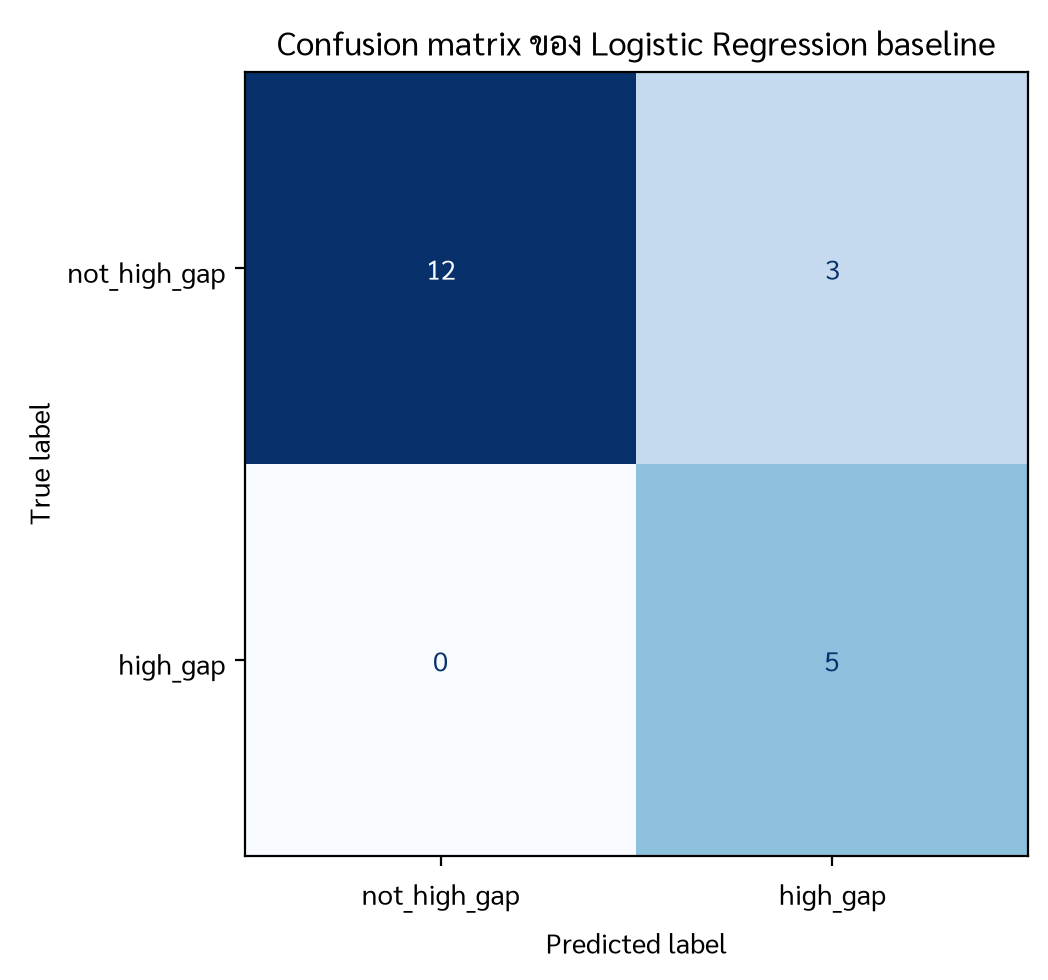

In [30]:
classification_confusion_matrix = confusion_matrix(y_test, classification_predictions)
fig, ax = plt.subplots(figsize=(6, 5))
display = ConfusionMatrixDisplay(
    confusion_matrix=classification_confusion_matrix,
    display_labels=["not_high_gap", "high_gap"],
)
display.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix ของ Logistic Regression baseline")
fig.tight_layout()
display_figure(fig)

## สรุป coefficient ของ classification model

coefficient แสดงทิศทางของ Logistic Regression หลัง standardization เท่านั้น ไม่ใช่ความเป็นเหตุเป็นผลหรือความสำคัญเชิงนโยบาย

In [31]:
logistic_regression_model = classification_model.named_steps["model"]
coefficient_df = pd.DataFrame(
    {
        "feature": CLASSIFICATION_FEATURE_COLUMNS,
        "coefficient": logistic_regression_model.coef_[0],
    }
).sort_values("coefficient")
coefficient_df

,feature,coefficient
3,area_nga_want_land_numeric,0.077297
6,area_nga_owner_numeric,0.077297
5,area_rai_owner_numeric,0.083938
2,area_rai_want_land_numeric,0.083938
4,area_wa_want_land,0.202430
7,area_wa_owner,0.202430
1,countowner,0.894950
0,countw,2.179239


## กราฟ coefficient ของ classification model

แหล่งข้อมูลคือ feature ที่ไม่ใช่ส่วนประกอบโดยตรงของ derived label กราฟใช้ดูทิศทางใน baseline เท่านั้น
ผลอาจเปลี่ยนเมื่อแบ่งข้อมูลใหม่หรือเมื่อ metadata มีการยืนยันเพิ่มเติม

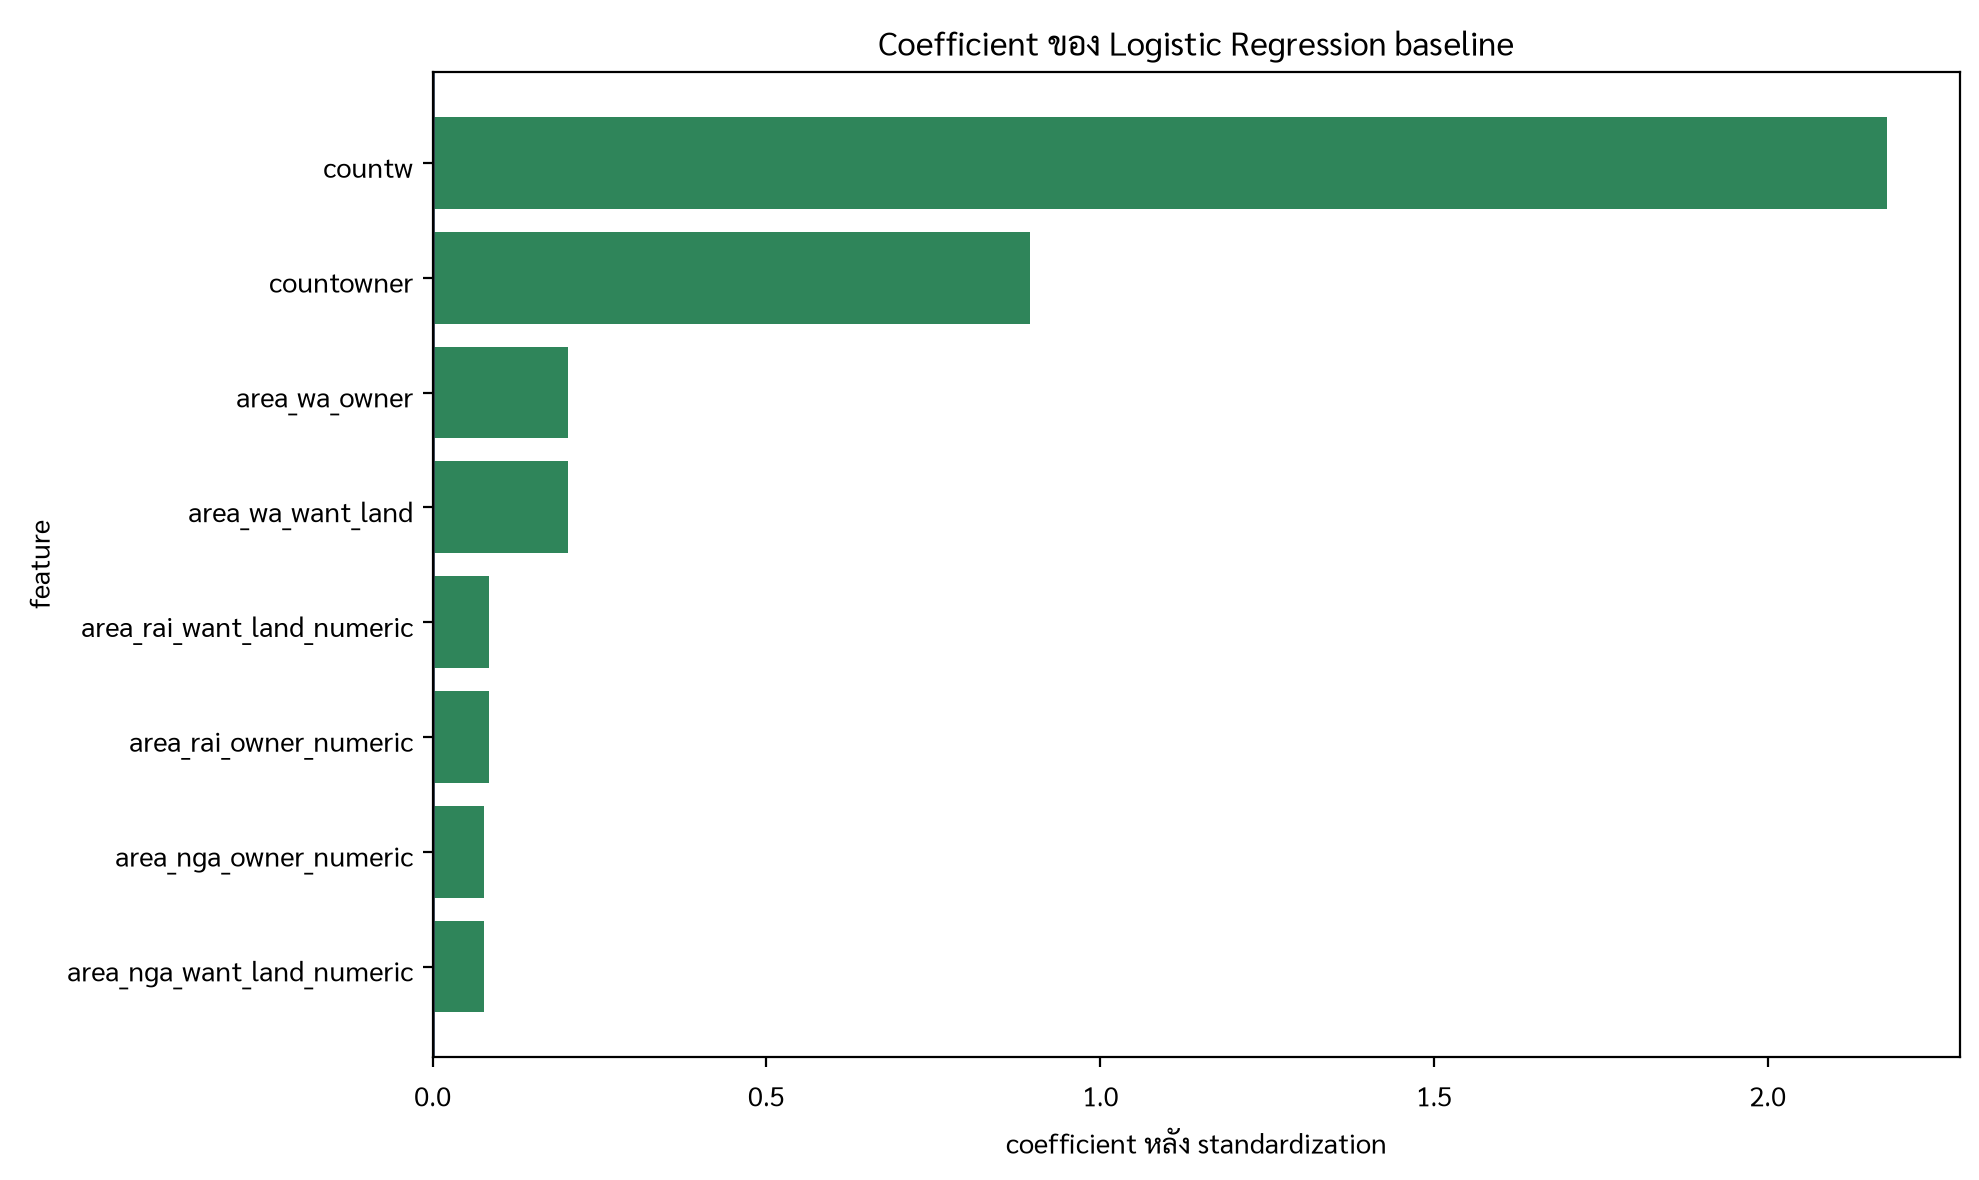

In [32]:
coefficient_colors = []

for coefficient_value in coefficient_df["coefficient"]:
    if coefficient_value >= 0:
        coefficient_colors.append("#2f855a")
    else:
        coefficient_colors.append("#c05621")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coefficient_df["feature"], coefficient_df["coefficient"], color=coefficient_colors)
ax.axvline(0, color="#334155", linewidth=1)
ax.set_title("Coefficient ของ Logistic Regression baseline")
ax.set_xlabel("coefficient หลัง standardization")
ax.set_ylabel("feature")
fig.tight_layout()
display_figure(fig)

## Regression baseline status

ไม่ทำ regression ในรอบนี้ เพราะความหมายและความเป็นอิสระของ feature กับ target ยังยืนยันไม่ได้
การบังคับใช้ regression อาจทำให้เกิด data leakage หรือข้อสรุปที่เกินกว่าข้อมูล 77 แถวรองรับ

In [33]:
regression_status_df = pd.DataFrame(
    [
        {
            "status": "not_run",
            "reason": "feature suitability และความหมายของ target ยังไม่ชัดเจนพอสำหรับ baseline ที่ตีความได้",
        }
    ]
)
regression_status_df

,status,reason
0,not_run,feature suitability และความหมายของ target ยังไ...


## สร้าง Plotly clustering chart สำหรับ HTML report

กราฟ interactive นี้แสดงผล PCA เดียวกับกราฟ static และใช้สำหรับทบทวน cluster profile ใน HTML

In [34]:
modeling_df["cluster_label"] = "กลุ่ม " + modeling_df["cluster_id"].astype(str)

cluster_plotly_figure = px.scatter(
    modeling_df,
    x="pca_component_1",
    y="pca_component_2",
    color="cluster_label",
    hover_name=PROVINCE_COLUMN,
    title="KMeans clustering baseline ของ LABAI ระดับจังหวัด",
    labels={
        "pca_component_1": "PCA component 1",
        "pca_component_2": "PCA component 2",
        "cluster_label": "กลุ่ม",
    },
)
cluster_plotly_figure.update_layout(
    template="plotly_white",
    height=650,
    font={"family": "Sarabun, system-ui, sans-serif"},
    hoverlabel={"font": {"family": "Sarabun, system-ui, sans-serif"}},
)

## สร้าง Plotly cluster profile chart สำหรับ HTML report

heatmap แสดงค่า standardized ของ cluster means เพื่อเปรียบเทียบ profile ระหว่างกลุ่มในรายงาน HTML

In [35]:
profile_plotly_figure = go.Figure(
    data=go.Heatmap(
        z=standardized_profile_array,
        x=profile_value_columns,
        y=cluster_profiles_df["cluster_id"].astype(str),
        colorscale="RdBu_r",
        colorbar={"title": "standardized mean"},
    )
)
profile_plotly_figure.update_layout(
    title="เปรียบเทียบ cluster profile หลัง standardization",
    xaxis_title="profile columns",
    yaxis_title="cluster_id",
    template="plotly_white",
    height=500,
    font={"family": "Sarabun, system-ui, sans-serif"},
    hoverlabel={"font": {"family": "Sarabun, system-ui, sans-serif"}},
)

## สร้าง Plotly confusion matrix สำหรับ HTML report

กราฟนี้สรุปผล classification baseline ของ derived label เท่านั้น

In [36]:
classification_plotly_figure = go.Figure(
    data=go.Heatmap(
        z=classification_confusion_matrix,
        x=["not_high_gap", "high_gap"],
        y=["not_high_gap", "high_gap"],
        colorscale="Blues",
        text=classification_confusion_matrix,
        texttemplate="%{text}",
        colorbar={"title": "จำนวนแถว"},
    )
)
classification_plotly_figure.update_layout(
    title="Confusion matrix ของ Logistic Regression baseline",
    xaxis_title="ค่าที่ model ทำนาย",
    yaxis_title="label ที่สร้างจากกติกา",
    template="plotly_white",
    height=500,
    font={"family": "Sarabun, system-ui, sans-serif"},
    hoverlabel={"font": {"family": "Sarabun, system-ui, sans-serif"}},
)

## Export Phase 4 HTML report

รายงาน HTML ฝัง Plotly JavaScript ใน fragment แรกเพื่อเปิดทบทวนได้โดยไม่ต้องพึ่งพา CDN
เนื้อหารายงานเรียง clustering ก่อน classification และระบุว่า regression ไม่ได้ทำในรอบนี้

In [37]:
cluster_plotly_html = pio.to_html(cluster_plotly_figure, full_html=False, include_plotlyjs=True)
profile_plotly_html = pio.to_html(profile_plotly_figure, full_html=False, include_plotlyjs=False)
classification_plotly_html = pio.to_html(classification_plotly_figure, full_html=False, include_plotlyjs=False)

phase4_html_report = f"""<!DOCTYPE html>
<html lang='th'>
<head>
  <meta charset='utf-8'>
  <meta name='viewport' content='width=device-width, initial-scale=1'>
  <title>LABAI Phase 4 Exploratory Baseline ML</title>
  <style>
    @font-face {{ font-family: "Sarabun"; src: url("../../Sarabun-Regular.ttf") format("truetype"); font-style: normal; font-weight: 400; font-display: swap; }}
    body, h1, h2, p, li, table, th, td, .note, .warning, .font-note {{ font-family: "Sarabun", system-ui, sans-serif; }}
    body {{ margin: 0; padding: 32px; background: #f5f7f8; color: #1f2933; font-family: "Sarabun", system-ui, sans-serif; line-height: 1.6; }}
    main {{ max-width: 1240px; margin: 0 auto; }}
    h1, h2 {{ color: #123b42; }}
    section {{ background: #ffffff; border: 1px solid #d8e2e5; margin: 20px 0; padding: 20px; }}
    .note {{ border-left: 4px solid #0f766e; background: #effaf8; padding: 12px; }}
    .warning {{ border-left: 4px solid #b45309; background: #fffbeb; padding: 12px; }}
    table {{ border-collapse: collapse; width: 100%; }}
    th, td {{ border: 1px solid #d8e2e5; padding: 8px; text-align: left; }}
    th {{ background: #eaf4f3; }}
    .font-note {{ color: #52616b; font-size: 14px; margin-top: 0; }}
    .report-nav {{ display: flex; flex-wrap: wrap; gap: 8px; margin: 0 0 24px; padding: 10px 12px; background: #ffffff; border: 1px solid #d8e2e5; border-radius: 6px; }}
    .report-nav a {{ color: #0f5c75; padding: 4px 8px; }}
    footer {{ border-top: 1px solid #cbd5e1; margin-top: 36px; padding-top: 16px; color: #52616b; font-size: 14px; }}
  </style>
</head>
<body>
  <main>
    <nav class="report-nav" aria-label="การนำทางรายงาน">
      <a href="../../">หน้าแรก</a>
      <a href="final_summary.html">รายงานสรุป</a>
      <a href="interactive_data_report.html">รายงานข้อมูล interactive</a>
      <a href="ml_baseline_report.html">รายงาน ML baseline</a>
      <a href="https://github.com/1-brain-cell/dga306-july2026-group7/tree/master/notebooks">Notebooks</a>
    </nav>
    <h1>LABAI Phase 4: Exploratory Baseline ML</h1>
    <p>รายงานนี้ใช้ข้อมูล cleaned demand/supply ระดับจังหวัด 77 แถว เพื่อสาธิต clustering และ classification baseline ไม่ใช่ production model</p>
    <p class='font-note'>รายงานใช้ Sarabun จาก `../../Sarabun-Regular.ttf` เมื่อเบราว์เซอร์เข้าถึงไฟล์ได้ หากเข้าถึงไม่ได้ รายงานจะใช้ system font เป็น fallback และยังคงอ่านเนื้อหาและกราฟได้</p>
    <section>
      <h2>Clustering baseline</h2>
      <p class='note'>เลือก KMeans k=3 เพื่อความอ่านง่าย แม้ silhouette score ของ k ที่มากกว่าต่างกันเพียงเล็กน้อย สีและระยะห่างเป็นผลของ baseline ไม่ใช่คะแนนศักยภาพของจังหวัด</p>
      {cluster_plotly_html}
      {profile_plotly_html}
    </section>
    <section>
      <h2>Classification baseline</h2>
      <p class='note'>label `high_gap` สร้างจาก quantile 75% ของ `count_gap_want_minus_owner` และเป็น label เพื่อการศึกษา ไม่ใช่สถานะทางการ</p>
      <p>Accuracy {classification_metrics_df.iloc[0]["accuracy"]:.3f}, Precision {classification_metrics_df.iloc[0]["precision"]:.3f}, Recall {classification_metrics_df.iloc[0]["recall"]:.3f}, F1-score {classification_metrics_df.iloc[0]["f1_score"]:.3f} บน test set {int(classification_metrics_df.iloc[0]["test_row_count"])} แถว</p>
      {classification_plotly_html}
    </section>
    <section>
      <h2>Regression status</h2>
      <p class='warning'>ไม่ทำ regression เพราะ feature suitability และความหมายของ target ยังไม่ชัดเจนพอ การข้าม model เป็นการจำกัดขอบเขตตามคุณภาพข้อมูล</p>
    </section>
    <section>
      <h2>ข้อจำกัดและข้อเสนอ</h2>
      <ul>
        <li>ข้อมูลมีเพียง 77 แถวระดับจังหวัด และมี outlier หลาย column</li>
        <li>ไม่ใช้ field การจับคู่เป็น target เพราะ `-` ยังไม่มีความหมายที่ยืนยันได้</li>
        <li>ควรใช้ cluster เพื่อเลือกหัวข้อที่ต้องตรวจ metadata หรือเก็บข้อมูลเพิ่ม ไม่ใช่ตัดสินจังหวัด</li>
      </ul>
    </section>
    <footer>
      <div>รายงานใช้ Sarabun จาก `../../Sarabun-Regular.ttf` เมื่อเบราว์เซอร์เข้าถึงไฟล์ได้ หากเข้าถึงไม่ได้ รายงานจะใช้ system font เป็น fallback และยังคงอ่านเนื้อหาและกราฟได้</div>
      <nav class="report-nav" aria-label="การนำทางรายงานท้ายหน้า">
        <a href="../../">หน้าแรก</a>
        <a href="final_summary.html">รายงานสรุป</a>
        <a href="interactive_data_report.html">รายงานข้อมูล interactive</a>
        <a href="ml_baseline_report.html">รายงาน ML baseline</a>
        <a href="https://github.com/1-brain-cell/dga306-july2026-group7/tree/master/notebooks">Notebooks</a>
      </nav>
    </footer>
  </main>
</body>
</html>
"""
HTML_REPORT_FILE.write_text(phase4_html_report, encoding="utf-8")

4887364

## ตรวจการตั้งค่า font ของรายงาน HTML

ตรวจว่ารายงานที่สร้างมี local font path, CSS fallback และ Plotly runtime โดยไม่ประเมินหรือฝึก model เพิ่ม

In [38]:
phase4_report_text = HTML_REPORT_FILE.read_text(encoding="utf-8")
phase4_html_validation = {
    "has_sarabun_css": 'font-family: "Sarabun", system-ui, sans-serif' in phase4_report_text,
    "has_local_font_path": "../../Sarabun-Regular.ttf" in phase4_report_text,
    "has_font_fallback_note": "system font เป็น fallback" in phase4_report_text,
    "has_plotly_chart_code": "Plotly.newPlot" in phase4_report_text,
}

if not all(phase4_html_validation.values()):
    raise ValueError("รายงาน HTML ของ Phase 4 ไม่ผ่านการตรวจการตั้งค่า font หรือ Plotly")

pd.DataFrame([phase4_html_validation])

,has_sarabun_css,has_local_font_path,has_font_fallback_note,has_plotly_chart_code
0,True,True,True,True


## Model limitations

ข้อมูลมี 77 แถว, มี outlier หลาย column, ไม่มีเวลา และ metadata ของ count กับ area fields ยังมีข้อจำกัด
metric และ profile จึงใช้ประกอบการเรียนรู้และการตรวจข้อมูล ไม่ใช่ผลที่นำไปใช้ตัดสินใจเชิงปฏิบัติการ

In [39]:
model_limitations_df = pd.DataFrame(
    [
        {"limitation": "sample size", "detail": "77 แถวระดับจังหวัด ทำให้ metric มีความผันผวน"},
        {"limitation": "outliers", "detail": "พบ outlier ตาม IQR ในหลาย clustering features"},
        {"limitation": "derived label", "detail": "high_gap เป็น label ที่สร้างจากกติกา ไม่ใช่ label ต้นทาง"},
        {"limitation": "matching field", "detail": "ไม่ใช้เป็น target เพราะ - ยังไม่ยืนยันความหมาย"},
        {"limitation": "regression", "detail": "ไม่ทำเพราะ feature suitability ยังไม่ชัดเจน"},
    ]
)
model_limitations_df

,limitation,detail
0,sample size,77 แถวระดับจังหวัด ทำให้ metric มีความผันผวน
1,outliers,พบ outlier ตาม IQR ในหลาย clustering features
2,derived label,high_gap เป็น label ที่สร้างจากกติกา ไม่ใช่ la...
3,matching field,ไม่ใช้เป็น target เพราะ - ยังไม่ยืนยันความหมาย
4,regression,ไม่ทำเพราะ feature suitability ยังไม่ชัดเจน


## Prescriptive recommendations

ข้อเสนอเป็นขั้นตอนการตรวจข้อมูลและการเก็บข้อมูลเพิ่มจากข้อจำกัดของ baseline ไม่ใช่คำสั่งเชิงนโยบาย

In [40]:
prescriptive_recommendations_df = pd.DataFrame(
    [
        {
            "recommendation": "ตรวจ metadata ของ count และ area fields",
            "reason": "ยืนยันหน่วยและความหมายก่อนเพิ่ม feature หรือ regression",
        },
        {
            "recommendation": "ตรวจจังหวัดใน cluster ที่มีจำนวนสมาชิกน้อย",
            "reason": "ประเมินว่าเป็น pattern ข้อมูลหรือผลจาก outlier ก่อนตีความต่อ",
        },
        {
            "recommendation": "ยืนยันความหมายของ - ในข้อมูลการจับคู่",
            "reason": "จำเป็นก่อนใช้ field การจับคู่เป็น target หรือคำนวณอัตรา",
        },
        {
            "recommendation": "เก็บข้อมูลตามช่วงเวลาเพิ่ม",
            "reason": "ช่วยประเมินการเปลี่ยนแปลงและลดข้อจำกัดของข้อมูล snapshot ระดับจังหวัด",
        },
    ]
)
prescriptive_recommendations_df

,recommendation,reason
0,ตรวจ metadata ของ count และ area fields,ยืนยันหน่วยและความหมายก่อนเพิ่ม feature หรือ r...
1,ตรวจจังหวัดใน cluster ที่มีจำนวนสมาชิกน้อย,ประเมินว่าเป็น pattern ข้อมูลหรือผลจาก outlier...
2,ยืนยันความหมายของ - ในข้อมูลการจับคู่,จำเป็นก่อนใช้ field การจับคู่เป็น target หรือค...
3,เก็บข้อมูลตามช่วงเวลาเพิ่ม,ช่วยประเมินการเปลี่ยนแปลงและลดข้อจำกัดของข้อมู...


## แหล่งข้อมูล

source URL หลักของ demand/supply คือ https://data.go.th/dataset/65_dataset_11_03

ดูรายละเอียด dataset และข้อจำกัดเพิ่มเติมได้ที่ `docs/data_sources.md` และ `docs/limitations.md`
